In [6]:
%matplotlib inline
import importlib
from md_engine import MDSimulation, SimulationConfig
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import Boltzmann
import scipy as sp

In [ ]:
# default configuration for the simulation

sim = MDSimulation(SimulationConfig())
if __name__ == "__main__":
    result = sim.run(run_diag=False,plot_msd=False,plot_rdf=False)


System: N = 256 atoms, L = 6.7184 σ
ε/k_B = 162.5467 K   (ε = 1.4000e-02 eV,  k_B = 1.380649e-23 J/K)
T* values: [0.01, 0.2, 0.4, 0.6, 0.8, 1.0]
Equivalent T (K): [1.625, 32.509, 65.019, 97.528, 130.037, 162.547]
Launching 6 tasks across 6 workers...

  [T* = 0.800 | T = 130.04 K]  equilibrating (2000 steps)...  [T* = 0.200 | T = 32.51 K]  equilibrating (2000 steps)...  [T* = 0.010 | T = 1.63 K]  equilibrating (2000 steps)...  [T* = 0.400 | T = 65.02 K]  equilibrating (2000 steps)...  [T* = 1.000 | T = 162.55 K]  equilibrating (2000 steps)...  [T* = 0.600 | T = 97.53 K]  equilibrating (2000 steps)...





  [T* = 0.200]  production (4000 steps)...
  [T* = 0.010]  production (4000 steps)...
  [T* = 0.400]  production (4000 steps)...
  [T* = 0.800]  production (4000 steps)...
  [T* = 0.600]  production (4000 steps)...
  [T* = 1.000]  production (4000 steps)...


In [8]:
print(SimulationConfig.r_cutoff)

2.5


## Pressure calcs

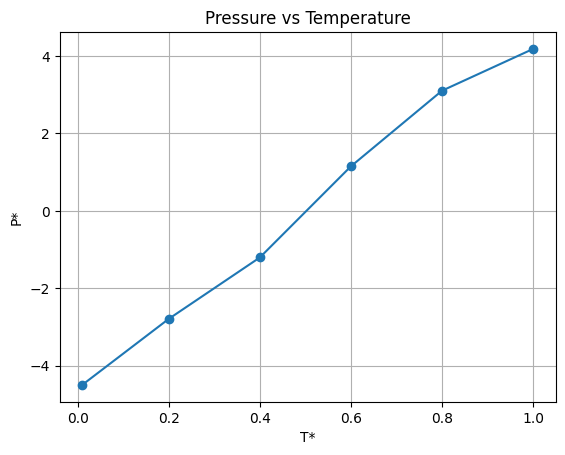

In [25]:
def get_pressure(r,g_r,rho_star,T_star,sim):
    r_squared = r**2
    _,forces = sim._calculate_lennard_jones_properties(r_squared,SimulationConfig.r_cutoff**2)
    integral = sp.integrate.simpson(forces*r_squared**2*g_r, x=r)
    P_star = rho_star*T_star + (2.0/3)*np.pi*rho_star**2*integral
    return P_star


P_star = []
rho_star = SimulationConfig.rho_star
for i in range(len(result)):
    r = result[i].r_centers
    g_r = result[i].g_avg
    T_star = result[i].T_star
    P_star.append(get_pressure(r,g_r,rho_star,T_star,sim))

T_stars = [res.T_star for res in result]
plt.plot(T_stars, P_star, marker='o')
plt.xlabel('T*')
plt.ylabel('P*')
plt.title('Pressure vs Temperature')
plt.grid()
plt.show()

## Internal energy calcs

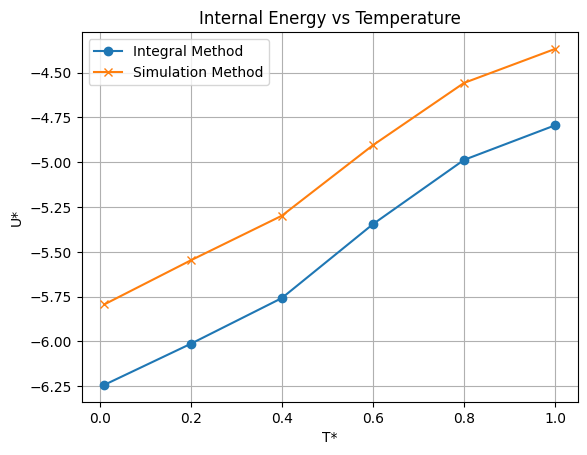

In [41]:
g_r = result[-1].g_avg
r = result[-1].r_centers
rho_star = SimulationConfig.rho_star

def get_internal_energy(g_r, r, rho_star):
    potential_energy, _ = sim._calculate_lennard_jones_properties(r**2, SimulationConfig.r_cutoff**2)
    integral = sp.integrate.simpson(potential_energy*g_r*r**2, x=r)
    U_star = 2*np.pi*rho_star*integral
    return U_star

U_star_integral = []
U_star_simulation = []
for i in range(len(result)):
    g_r = result[i].g_avg
    r = result[i].r_centers
    U_star_integral.append(get_internal_energy(g_r, r, rho_star))
    U_star_simulation.append(np.mean(result[i].pot_E[SimulationConfig.equil_steps:])/(4*SimulationConfig.n_cells**3))

T_stars = [res.T_star for res in result]
plt.plot(T_stars, U_star_integral, marker='o', label='Integral Method')
plt.plot(T_stars, U_star_simulation, marker='x', label='Simulation Method')
plt.xlabel('T*')
plt.ylabel('U*')
plt.title('Internal Energy vs Temperature')
plt.legend()
plt.grid()
plt.show()

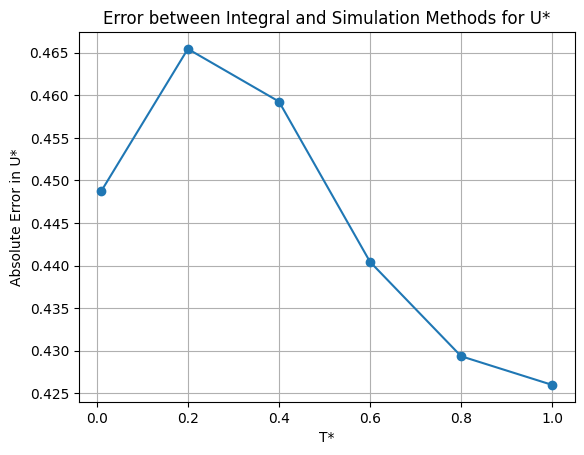

In [42]:
error = np.abs(np.array(U_star_integral) - np.array(U_star_simulation))
plt.plot(T_stars, error, marker='o')
plt.xlabel('T*')
plt.ylabel('Absolute Error in U*')
plt.title('Error between Integral and Simulation Methods for U*')
plt.grid()
plt.show()

## Structure factor

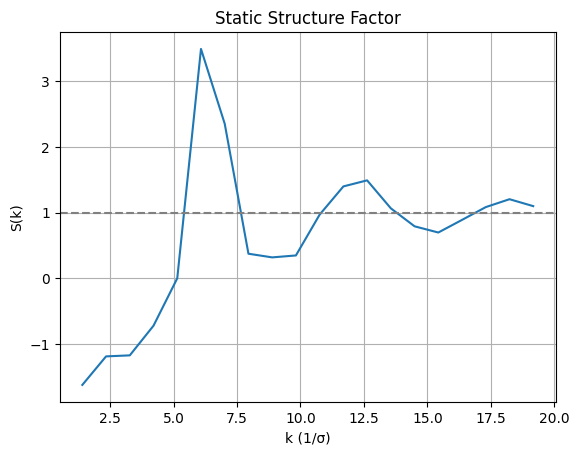

In [ ]:
dr = r[1] - r[0]
N  = len(r)
rho_star = SimulationConfig.rho_star

# IDK this
def get_structure_factor(dr, N, rho_star):
    sine_transform = sp.fft.dst(r * (g_r - 1), type=2) * dr
    k_values = np.pi * (np.arange(N) + 0.5) / (N * dr)
    S_k = 1 + 4 * np.pi * rho_star * sine_transform / k_values
    return k_values,S_k

k_values, S_k = get_structure_factor(dr, N, rho_star)

mask = (k_values >= 0.5) & (k_values <= 20.0)
plt.plot(k_values[mask], S_k[mask])
plt.xlabel("k (1/σ)")
plt.ylabel("S(k)")
plt.title("Static Structure Factor")
plt.axhline(1.0, color='gray', linestyle='--')
plt.grid()
plt.show()

## Lets try something with MSD now